# Chapter 11 – Root Finding with Built-In Python Tools

In this section, we will use **existing Python libraries** (mainly `numpy` and `scipy`) to find roots of equations numerically.

A **root** of a function \( f(x) \) is a value \( x = r \) such that:
$$
f(r) = 0.
$$

We will:

- Visualize where roots are located.
- Use `scipy.optimize.root_scalar` to find roots of general functions.
- Use `scipy.optimize.newton` for Newton’s method without implementing it ourselves.
- Use `numpy.roots` to find roots of **polynomials**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# SciPy optimization tools for root finding
from scipy import optimize

# Optional: nicer plots
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


## 11.1 Visualizing Roots

Before using root-finding algorithms, it's helpful to **plot** the function.

Example function:
$$
f(x) = x^3 - x - 2.
$$

We want to solve:
$$
x^3 - x - 2 = 0.
$$


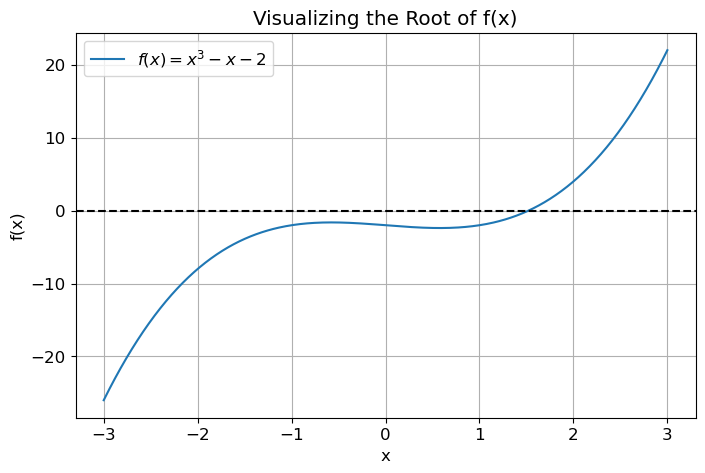

In [3]:
def f(x):
    return x**3 - x - 2

# Plot f(x) on an interval
x = np.linspace(-3, 3, 400)
y = f(x)

plt.plot(x, y, label=r"$f(x) = x^3 - x - 2$")
plt.axhline(0, color="k", linestyle="--")  # x-axis
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.title("Visualizing the Root of f(x)")
plt.show()


From the plot, the function crosses the x-axis between **x = 1** and **x = 2**.

So there is at least one root in the interval $$[1, 2]$$.


## 11.2 Using `scipy.optimize.root_scalar`

The function `scipy.optimize.root_scalar` can find a root of a **scalar** function.

One way to use it is by giving a **bracket** $$[a, b]$$ such that:
$$
f(a) \cdot f(b) < 0,
$$
meaning the function changes sign on $$[a, b]$$.

SciPy will internally use robust algorithms (like secant’s method) so we do not need to implement those ourselves.


In [18]:
# Use root_scalar with a bracket [1, 2]
sol_secant = optimize.root_scalar(f, method='secant', x0=1, x1=2)


print("Converged:", sol_bracket.converged)
print("Approximate root:", sol_bracket.root)
print("f(root) =", f(sol_bracket.root))


Converged: True
Approximate root: 1.5213797068045676
f(root) = 0.0


### 11.2.1 `root_scalar` with Newton's Method

`root_scalar` can also use **Newton's method**, but then it needs the derivative \( f'(x) \) and an initial guess \( x_0 \).

For our function:
$$
f(x) = x^3 - x - 2, \quad f'(x) = 3x^2 - 1.
$$


In [19]:
def fprime(x):
    return 3*x**2 - 1

# Using root_scalar with Newton's method
sol_newton_rs = optimize.root_scalar(f,fprime=fprime,x0=1.5,method='newton')

print("Converged:", sol_newton_rs.converged)
print("Approximate root (Newton via root_scalar):", sol_newton_rs.root)
print("f(root) =", f(sol_newton_rs.root))


Converged: True
Approximate root (Newton via root_scalar): 1.5213797068045676
f(root) = 0.0


## 11.4 Using `scipy.optimize.fsolve` to Find a Root

`fsolve` is another root-finding function in SciPy.  
It works well when we give it a **good initial guess** for the root.

We will solve:

$$
f(x) = x^3 - x - 2 = 0.
$$

Basic use:



In [12]:
from scipy import optimize
import numpy as np

def f(x):
    return x**3 - x - 2

# initial guess
x0 = 1.5

root = optimize.fsolve(f, x0)
print("Root from fsolve:", root)
print("f(root) =", f(root))

Root from fsolve: [1.52137971]
f(root) = [4.52970994e-14]


In [13]:
for guess in [0, 1, 2, 5]:
    r = optimize.fsolve(f, guess)
    print(f"Guess {guess} → root ≈ {r[0]:.6f}")


Guess 0 → root ≈ -0.577474
Guess 1 → root ≈ 1.521380
Guess 2 → root ≈ 1.521380
Guess 5 → root ≈ 1.521380


C:\Users\Bahaa\AppData\Local\Temp\ipykernel_4628\3154990760.py:2: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  r = optimize.fsolve(f, guess)


### Remark: Finding All Roots of a General Function

Python does **not** have a built-in function that automatically finds *all* roots of an arbitrary function.  
For non-polynomial functions, methods like `root_scalar`, `newton`, or `fsolve` can only find **one root at a time**, and they require:

- an **initial guess**, or  
- an **interval** where the function changes sign.

To locate multiple roots, we must usually:

1. **Plot the function** to see where it crosses the x-axis, or  
2. **Scan the domain** by breaking it into small intervals,  
3. Identify intervals where the function changes sign,  
4. Run the root-finding method **separately for each interval**.

Only for **polynomials** can we find all roots at once using `numpy.roots`.


## 11.5 Finding All Roots of a Polynomial Using `numpy.roots`

For polynomials, Python can find **all roots at once** (real and complex) using `numpy.roots`.

If we have a polynomial:

$$
p(x) = a_0 x^n + a_1 x^{n-1} + \dots + a_{n-1}x + a_n,
$$

we list its coefficients in order:

In [16]:
import numpy as np

# Example polynomial: p(x) = x^3 - x - 2
coeffs = [1, 0, -1, -2]

roots = np.roots(coeffs)
print("Roots:", roots)

Roots: [ 1.52137971+0.j         -0.76068985+0.85787363j -0.76068985-0.85787363j]


## Exercise: Solving a Bioengineering Root-Finding Problem

In many bioengineering systems, equilibrium or steady state occurs when two processes balance each other.  
Here we study **oxygen diffusion vs. cellular oxygen consumption** in tissue.

A simplified model gives the steady-state oxygen concentration $C$ as the solution to:

$$
f(C) = D(C_{\text{blood}} - C) - R_{\max}\,\frac{C}{K + C} = 0
$$

Where:
- $D$ = diffusion coefficient (assume 2.5)  
- $C_{\text{blood}}$ = oxygen concentration in blood (assume 8)  
- $R_{\max}$ = maximum cellular oxygen consumption (assume 3.5)  
- $K$ = Michaelis constant (assume 1.2)

This equation **cannot** be rearranged algebraically.  
We must solve for $C$ numerically.

---

### 1. Define the function in Python

```python
import numpy as np

D = 2.5
C_blood = 8
Rmax = 3.5
K = 1.2

def f(C):
    return D*(C_blood - C) - Rmax * (C / (K + C))
